In [1]:
#Kmedoid Program Complete


import wradlib as wrl
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import pairwise_distances as pdist

file_path = "C:\\Users\\manan\\OneDrive\\Desktop\\data\\BHP190610110229.MAXSU60"
fcontent = wrl.io.read_iris(file_path)
data = fcontent['data'][0][0]

data = data[200:,:520]
print(data.shape)

points = []
k=3

for indx,x in enumerate(data):
    for indy,y in enumerate(x):
        if y!=95.5 and y!=-32:
            points.append(list([indx,indy]))

def plotpoints(data,labels,centroids,k,save = False):
    color = ['red','blue','green','yellow','black','purple','grey']
    plt.figure(figsize = (20,20))
    for i in range(k):
        x = data[labels==i][:,0]
        y = data[labels==i][:,1]
        plt.scatter(x,y,s=1,c=color[i])

    for i in centroids:
        plt.scatter(i[0],i[1],s=100,c='orange')
    
    if save:
        plt.savefig('KMedoid.png')
    plt.show()

data = np.array(points)

np.random.seed(0)

previous_centroids = data[np.random.choice(len(data), k, replace=False)]
current_seeds = []
labels = []

def cost_function(cluster, data, labels):
    index = np.argmin(np.sum(pdist(data[labels==cluster], metric='euclidean'), axis=1))
    points = data[labels==cluster]
    return points[index]


(520, 520)


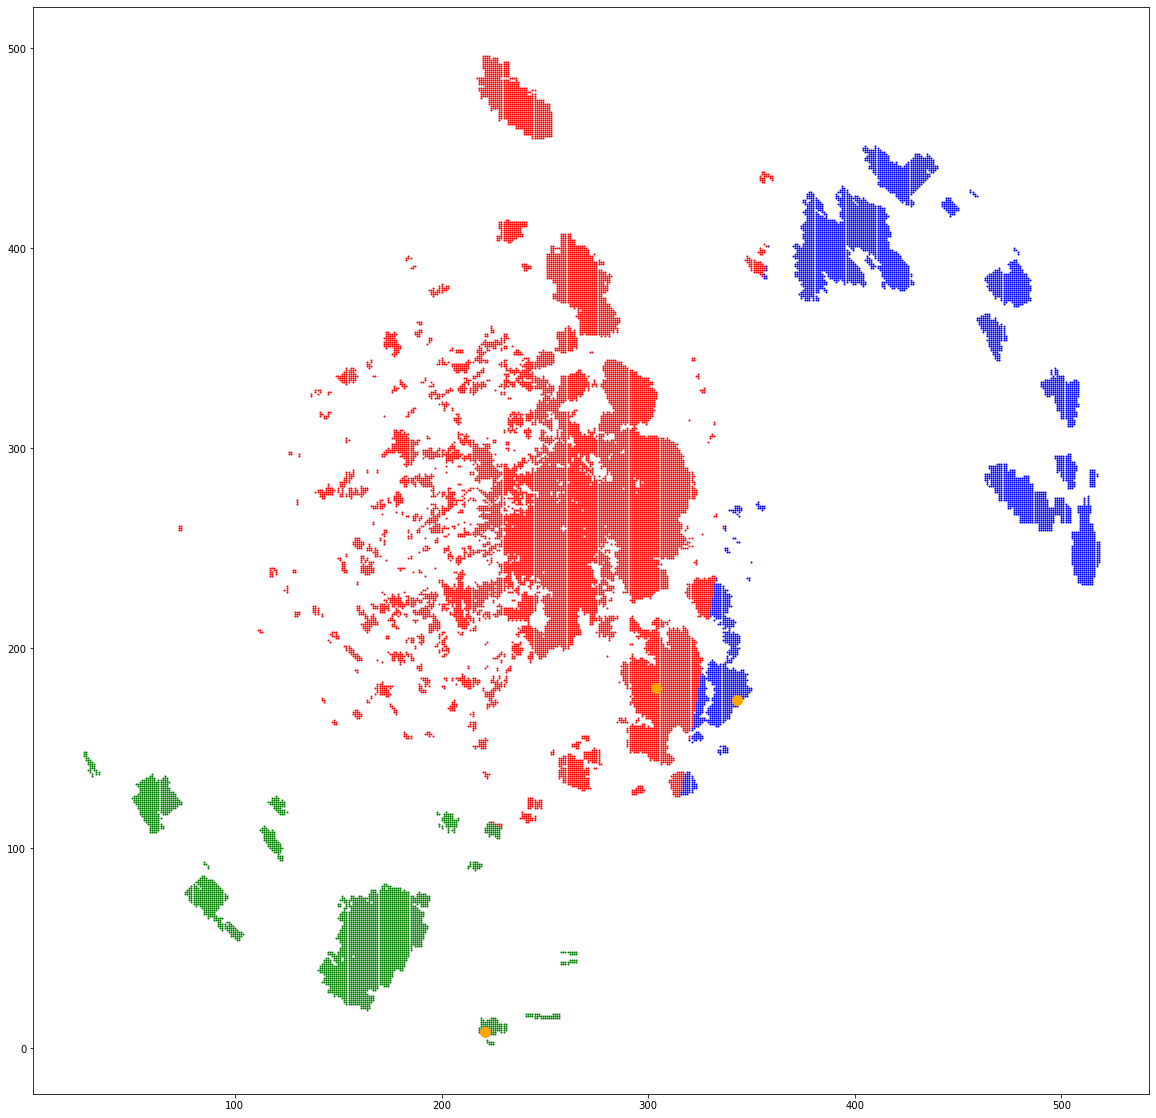

[[304 180]
 [343 174]
 [221   8]]


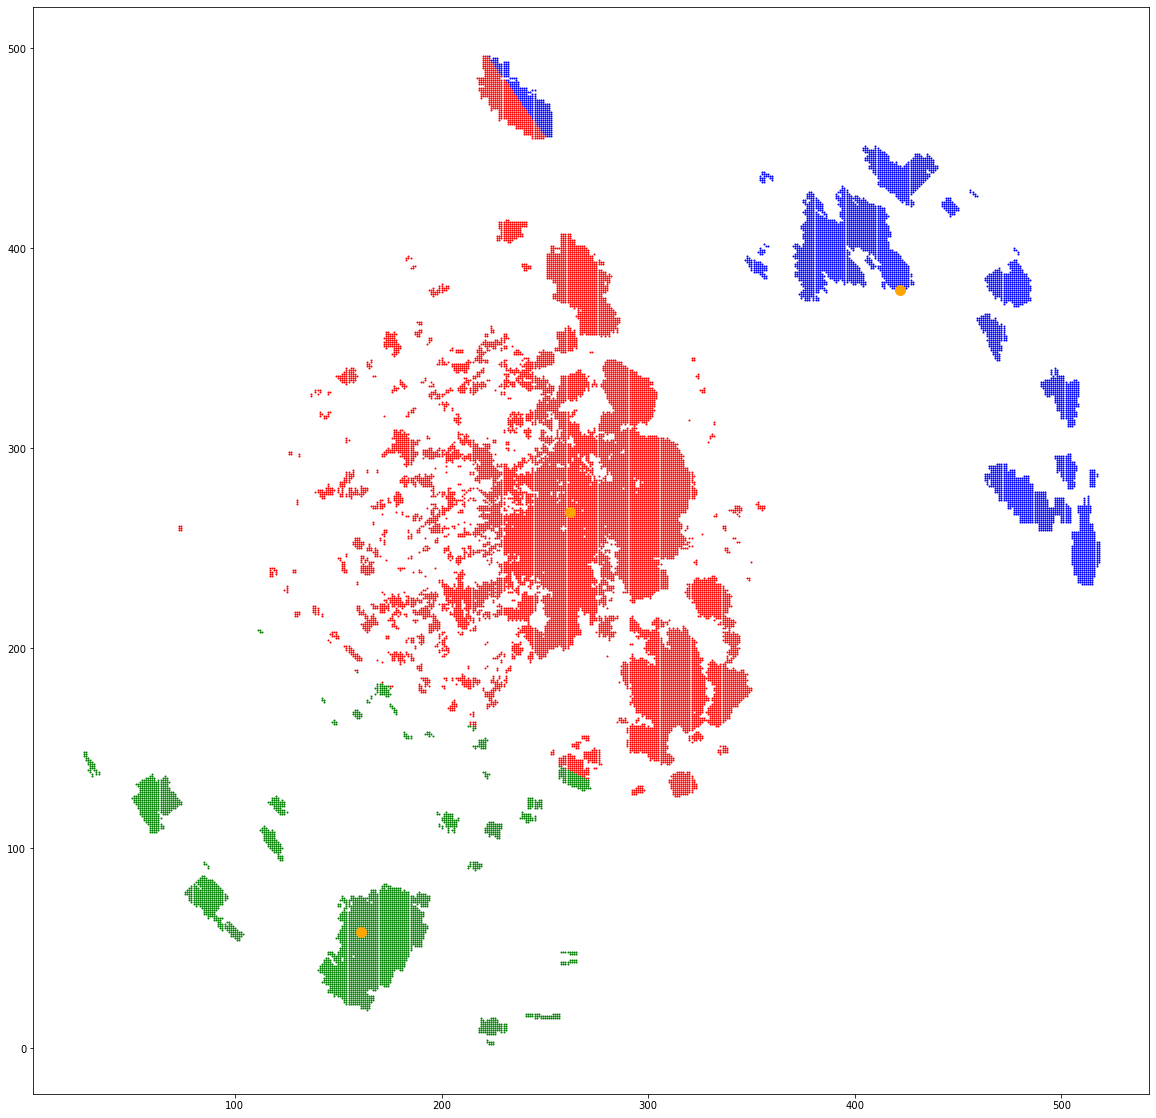

[[262 268]
 [422 379]
 [161  58]]


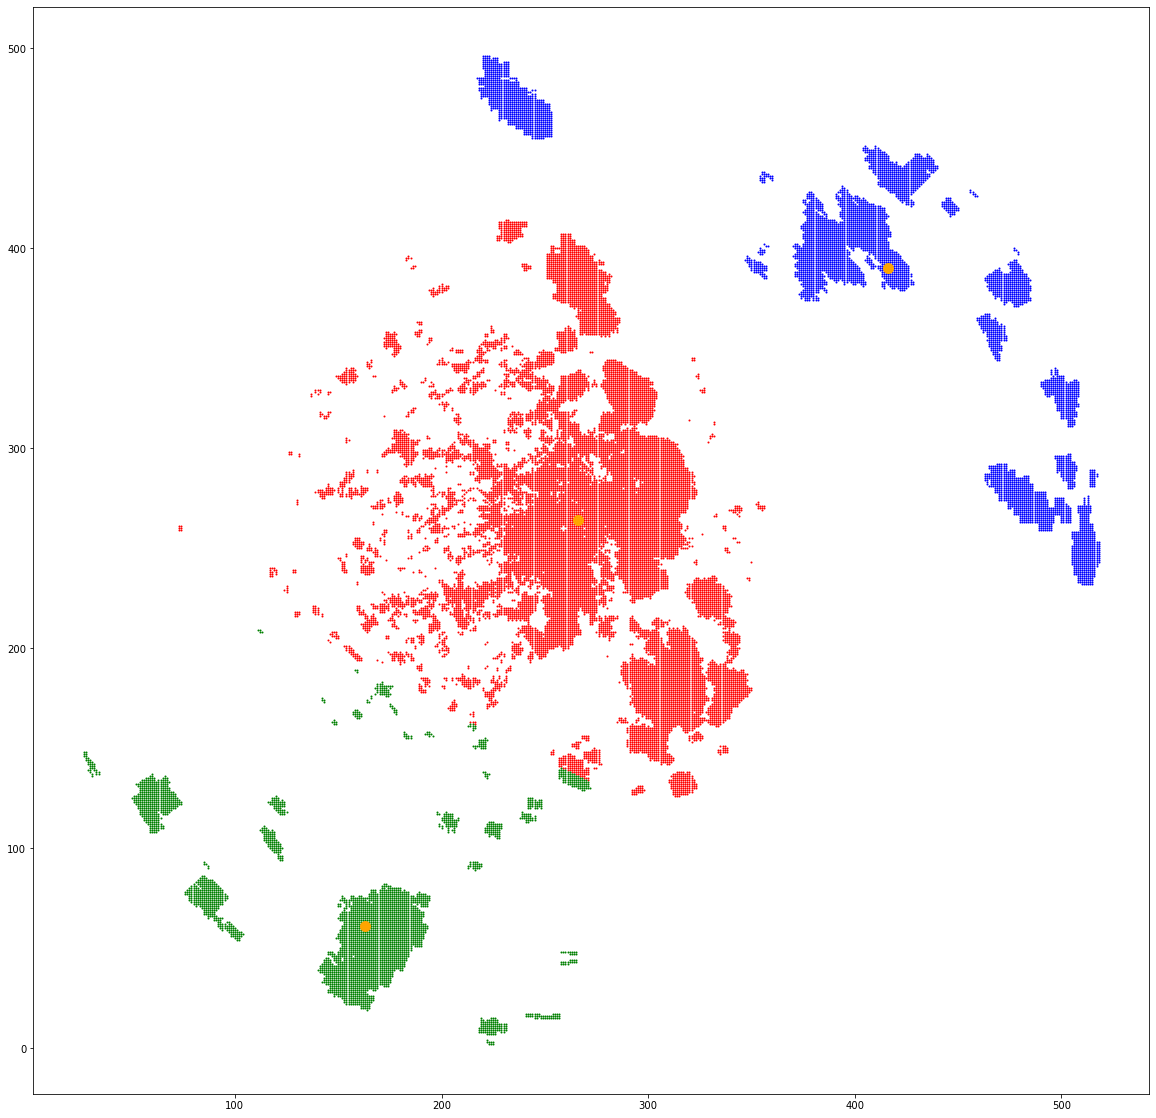

[[266 264]
 [416 390]
 [163  61]]


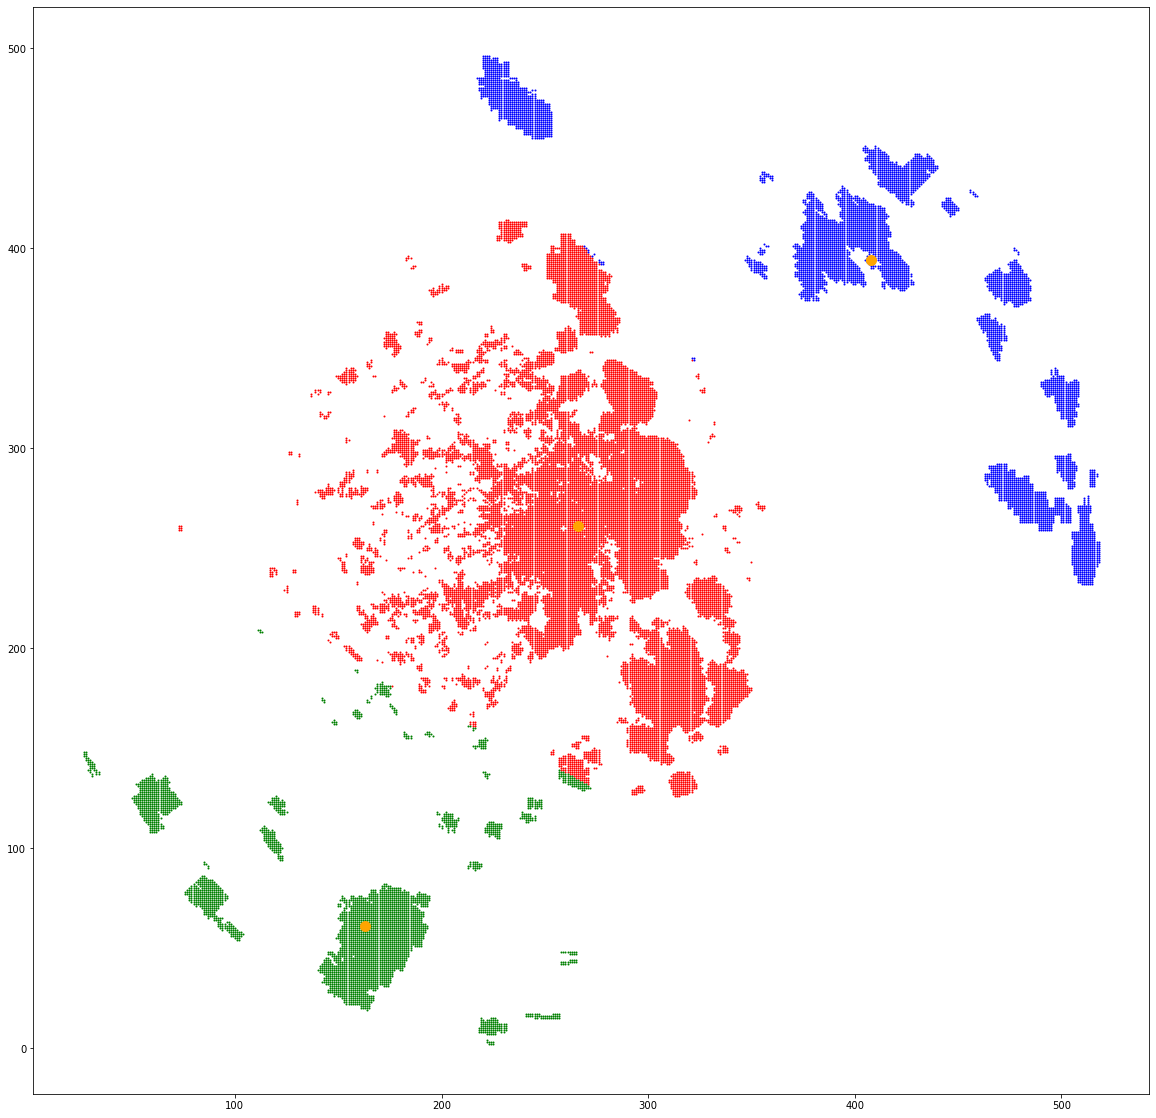

[[266 261]
 [408 394]
 [163  61]]
Final
[[266 261]
 [408 394]
 [163  61]]


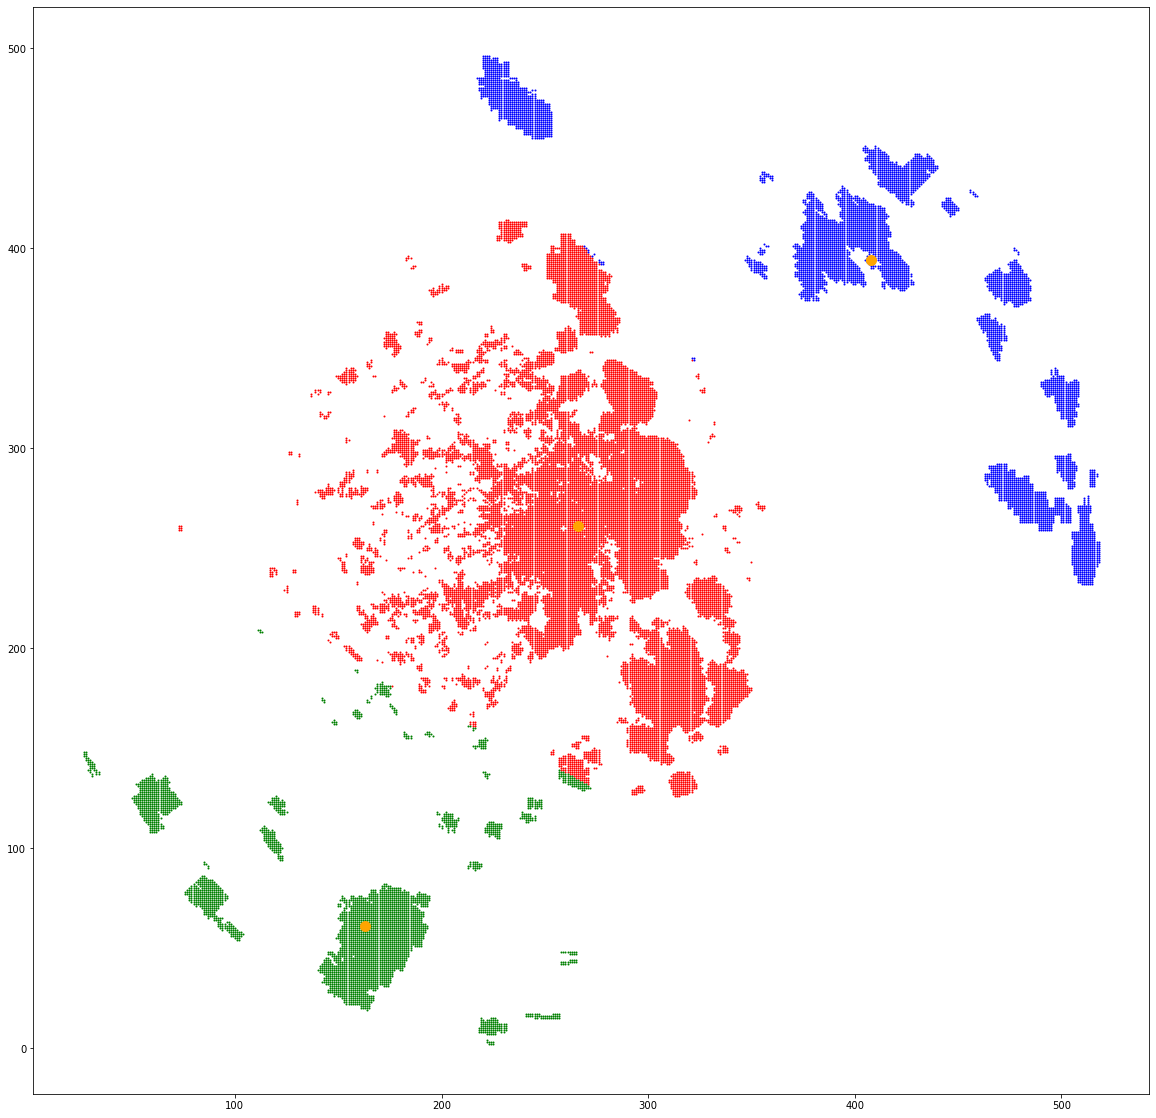

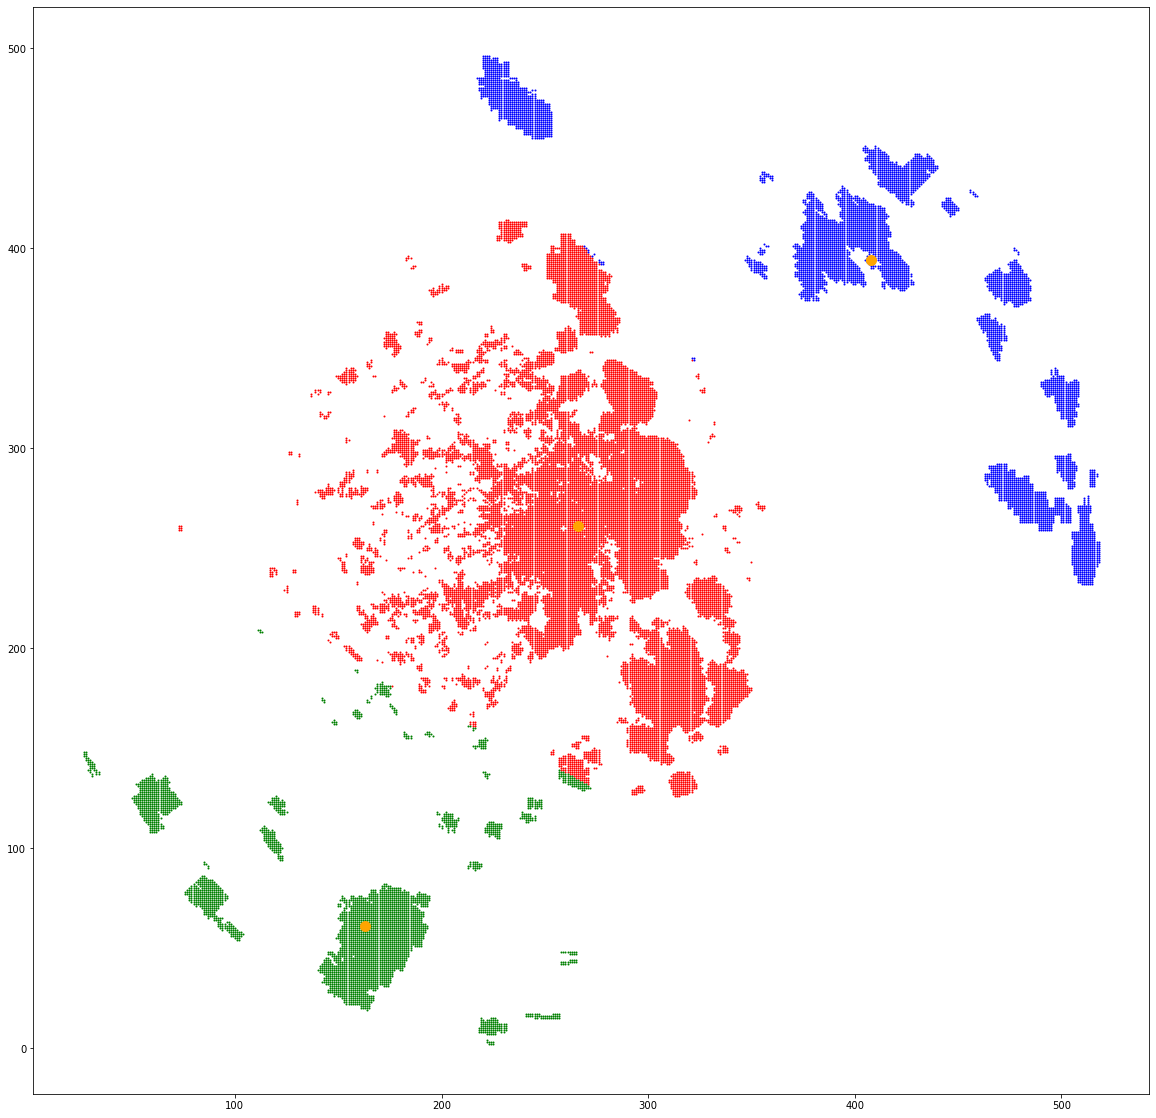

In [2]:
while True:
    labels = np.array([np.argmin(np.sqrt(np.sum((previous_centroids - data[i])**2, axis=1))) for i in range(len(data))])
    plotpoints(data,labels,previous_centroids,k)
    print(previous_centroids)
    current_centroids = np.array([cost_function(j,data,labels) for j in range(k)])
    if np.all(previous_centroids == current_centroids):
        print('Final')
        print(current_centroids)
        plotpoints(data,labels,previous_centroids,k)
        break;
    previous_centroids = current_centroids

plotpoints(data,labels,previous_centroids,k, save=True)